In [17]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import pymap3d as pm
import math
import seaborn as sb
import datetime as dt
import time

In [18]:
# BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/STATIC_GPS_FINAL.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
# VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/KINE_GPS_FINAL.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/STATIC_GPS_GAL_FINAL_C.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/KINE_GPS_GAL_FINAL.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

# BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/BASE_STATIC_GPS_ONLY.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
# VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/C_VBARF_STATIC_GPS_ONLY.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

# BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/DCB_OLD.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
# VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/DCB_NEW.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

In [19]:
def RMSE(data: pd.DataFrame):
    E_values = data.loc[data['E'].isna() == False, 'E']
    N_values = data.loc[data['N'].isna() == False, 'N']
    U_values = data.loc[data['U'].isna() == False, 'U']

    ppp_E_last = math.sqrt(sum(E_values**2) / len(E_values))
    ppp_N_last = math.sqrt(sum(N_values**2) / len(N_values))
    ppp_U_last = math.sqrt(sum(U_values**2) / len(U_values))

    print(f'RMSE E = {ppp_E_last:.4f}')
    print(f'RMSE N = {ppp_N_last:.4f}')
    print(f'RMSE U = {ppp_U_last:.4f}')

    print(f'2D = {((ppp_E_last+ppp_N_last)/2)*2.1460:.4f}')
    print(f'3D = {((ppp_E_last+ppp_N_last+ppp_U_last)*0.3333)*2.5003:.4f}')

In [20]:
ref_point = {'x': 54.9872753361111,
             'y': 82.864814275,
             'z': 109.647}

In [21]:
def reduction(df):
    enu = []
    for i in range(len(df)):
        enu.append(pm.geodetic2enu(df['latitude(deg)'][i], df['longitude(deg)'][i], df['height(m)'][i], 
                                ref_point['x'], ref_point['y'], ref_point['z']))

    df[['E','N','U']] = enu
    df['N'] += 0.1055 + 0.021
    df['U'] += 0.4187 - 0.054

    return df

In [22]:
import numpy as np
import pandas as pd
from scipy.stats import t

# Уровни значимости (α)
alphas = [0.4]  

# Степени свободы (ν)
dfs = [i for i in range(1,31)]

# Создаем таблицу
table = pd.DataFrame(index=dfs, columns=alphas)

for df in dfs:
    for alpha in alphas:
        # Двусторонний тест: t-критическое значение
        t_critical = t.ppf(1 - alpha / 2, df)
        table.loc[df, alpha] = f"{t_critical:.4f}"

# Переименуем индексы и столбцы для наглядности
table.index.name = "Степени свободы (ν)"
table.columns.name = "Уровень значимости (α)"
table.columns = [f"α = {a}" for a in alphas]

print("Таблица критических значений t-распределения (двусторонние):")
print(np.array(table['α = 0.4']))

Таблица критических значений t-распределения (двусторонние):
['1.3764' '1.0607' '0.9785' '0.9410' '0.9195' '0.9057' '0.8960' '0.8889'
 '0.8834' '0.8791' '0.8755' '0.8726' '0.8702' '0.8681' '0.8662' '0.8647'
 '0.8633' '0.8620' '0.8610' '0.8600' '0.8591' '0.8583' '0.8575' '0.8569'
 '0.8562' '0.8557' '0.8551' '0.8546' '0.8542' '0.8538']


RMSE E = 0.1765
RMSE N = 1.0136
RMSE U = 0.0162
2D = 1.2770
3D = 1.0053
RMSE E = 11.3403
RMSE N = 7.0443
RMSE U = 8.4681
2D = 19.7267
3D = 22.3777


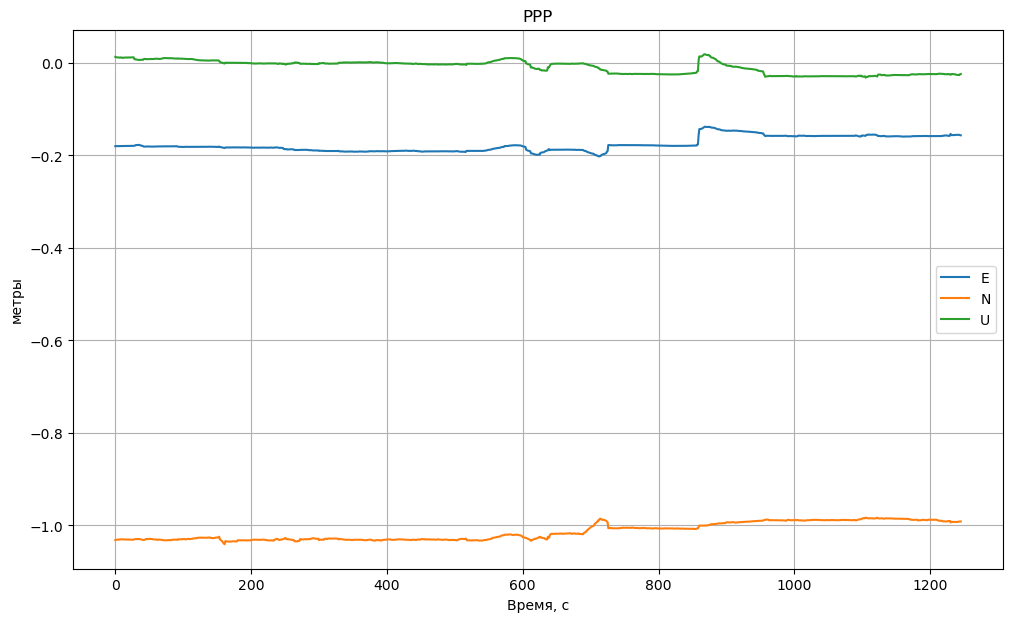

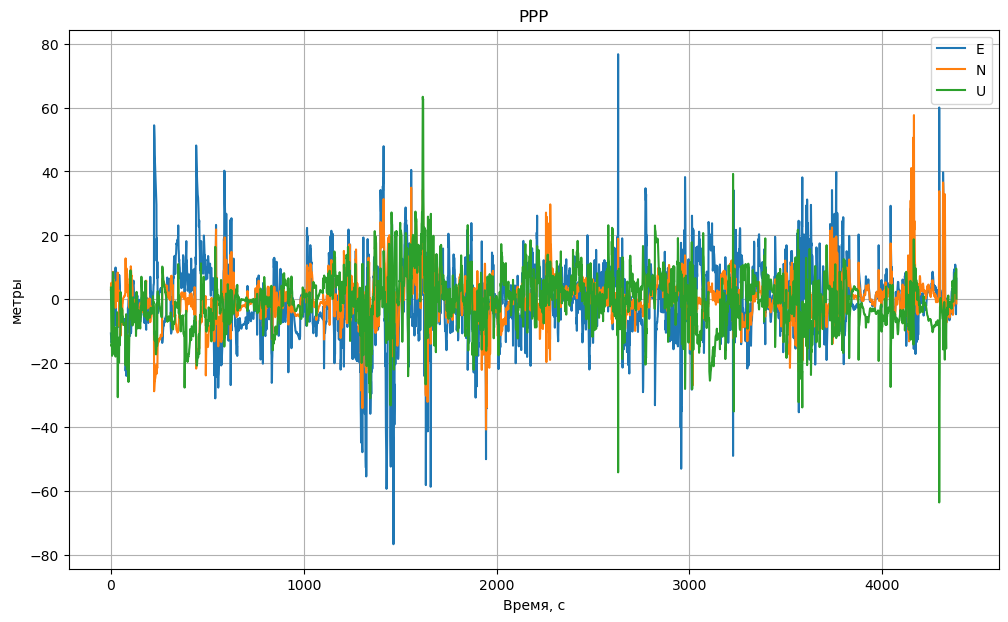

In [23]:
for i in [BASE, VBARF]:
    i = reduction(i)
    RMSE(i[:])
    i[:].plot(y=['E', 'N', 'U'], style='-', 
        grid=True, figsize=(12,7), xlabel='Время, с', 
        ylabel='метры', legend=True, title='PPP');